In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_excel("/kaggle/input/datasets/kohinrahman/kohinrahman/Air_BNB.xlsx")

In [3]:
data.drop('id',axis=1,inplace=True)

In [4]:
data.head()

,room_type,accommodates,bathrooms,cancellation_policy,cleaning_fee,instant_bookable,review_scores_rating,bedrooms,beds,log_price
0,Entire home/apt,3,1.0,strict,True,f,100.0,1.0,1.0,5.010635
1,Entire home/apt,7,1.0,strict,True,t,93.0,3.0,3.0,5.129899
2,Entire home/apt,5,1.0,moderate,True,t,92.0,1.0,3.0,4.976734
3,Entire home/apt,4,1.0,flexible,True,f,NaN,2.0,2.0,6.620073
4,Entire home/apt,2,1.0,moderate,True,t,40.0,0.0,1.0,4.744932


In [5]:
num = []
cat = []
bl = []
for i in data.columns:
    if data[i].dtype=='object':
        cat.append(i)
    elif data[i].dtype=='bool':
        bl.append(i)
    else:
        num.append(i)

In [6]:
num

['accommodates',
 'bathrooms',
 'review_scores_rating',
 'bedrooms',
 'beds',
 'log_price']

In [7]:
data[num].describe()

,accommodates,bathrooms,review_scores_rating,bedrooms,beds,log_price
count,74111.000000,73911.000000,57389.000000,74020.000000,73980.000000,74111.000000
mean,3.155146,1.235263,94.067365,1.265793,1.710868,4.782069
std,2.153589,0.582044,7.836556,0.852143,1.254142,0.717394
min,1.000000,0.000000,20.000000,0.000000,0.000000,0.000000
25%,2.000000,1.000000,92.000000,1.000000,1.000000,4.317488
50%,2.000000,1.000000,96.000000,1.000000,1.000000,4.709530
75%,4.000000,1.000000,100.000000,1.000000,2.000000,5.220356
max,16.000000,8.000000,100.000000,10.000000,18.000000,7.600402


<Axes: >

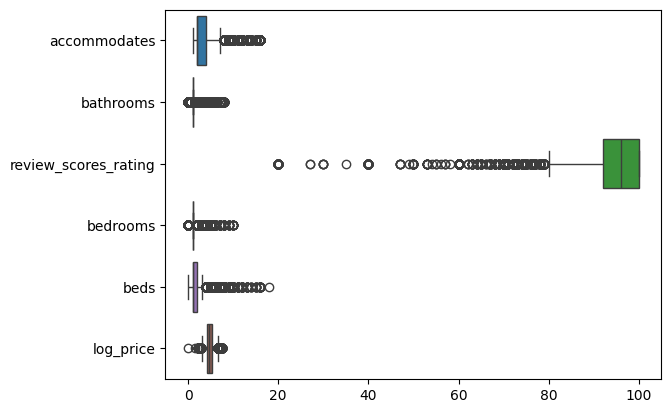

In [8]:
sns.boxplot(data[num],orient = 'h')

In [9]:
def outlier_trt(column):
    q1 = data[column].describe()['25%']
    q3 = data[column].describe()['75%']
    iqr = q3-q1
    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr
    return lower,upper

In [10]:
for i in num:
    lr,ur = outlier_trt(i)
    data[i] = np.where(data[i]>ur,ur,data[i])
    data[i] = np.where(data[i]<lr,lr,data[i])

<Axes: >

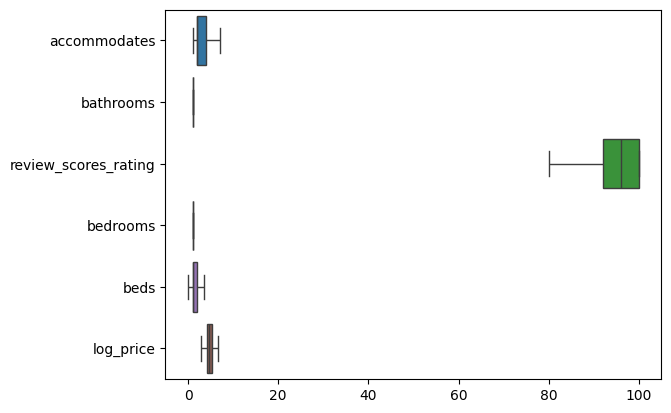

In [11]:
sns.boxplot(data[num],orient = 'h')